## Task 3 — Cuisine Classification
### Objective
Build a machine learning model to classify restaurants 
based on their **Primary Cuisine** type.

### Approach
- Load cleaned dataset
- Handle class imbalance
- Train 3 models: Logistic Regression → Random Forest → XGBoost
- Evaluate using Accuracy, Precision, Recall, F1-Score
- Plot Confusion Matrix
- Analyze challenges and biases

In [1]:
# Task 3 — Cuisine Classification

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ML - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ML - Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Model saving
import joblib

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")

print(" All libraries loaded successfully")

 All libraries loaded successfully


In [3]:
# Load cleaned dataset
df = pd.read_csv('../data/restaurant_cleaned.csv')

print(f"Dataset Shape : {df.shape}")
print(f"Total Restaurants : {df.shape[0]}")
df.head()

Dataset Shape : (9542, 14)
Total Restaurants : 9542


,Restaurant Name,Country Code,City,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes
0,Le Petit Souffle,162,Makati City,"Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,1,0,0,3,4.8,314
1,Izakaya Kikufuji,162,Makati City,"Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,1,0,0,3,4.5,591
2,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,1,0,0,4,4.4,270
3,Ooma,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,0,0,0,4,4.9,365
4,Sambo Kojin,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,1,0,0,4,4.8,229


## Step 1 — Prepare Target Variable (Cuisine)

**Challenge:** The `Cuisines` column contains multiple cuisines
per restaurant (e.g., "North Indian, Chinese, Italian").

**Solution:** Extract the PRIMARY cuisine (first one listed)
and classify based on that.

**Another Challenge:** There are 100+ unique cuisines — most
with very few restaurants. We keep only TOP 10 cuisines
and group the rest as 'Other'.

In [4]:
# Prepare Target Variabl

df_model = df.copy()

# Step 1: Extract primary cuisine (first cuisine listed)
df_model['Primary Cuisine'] = df_model['Cuisines'].apply(
    lambda x: x.split(',')[0].strip() if pd.notnull(x) else 'Unknown'
)

print("Top 20 cuisines before grouping:")
print(df_model['Primary Cuisine'].value_counts().head(20))

Top 20 cuisines before grouping:
Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Name: count, dtype: int64


Top 10 Cuisines selected:
['North Indian', 'Chinese', 'Fast Food', 'Bakery', 'Cafe', 'American', 'South Indian', 'Mithai', 'Street Food', 'Continental']

Dataset size after filtering: 7014 restaurants


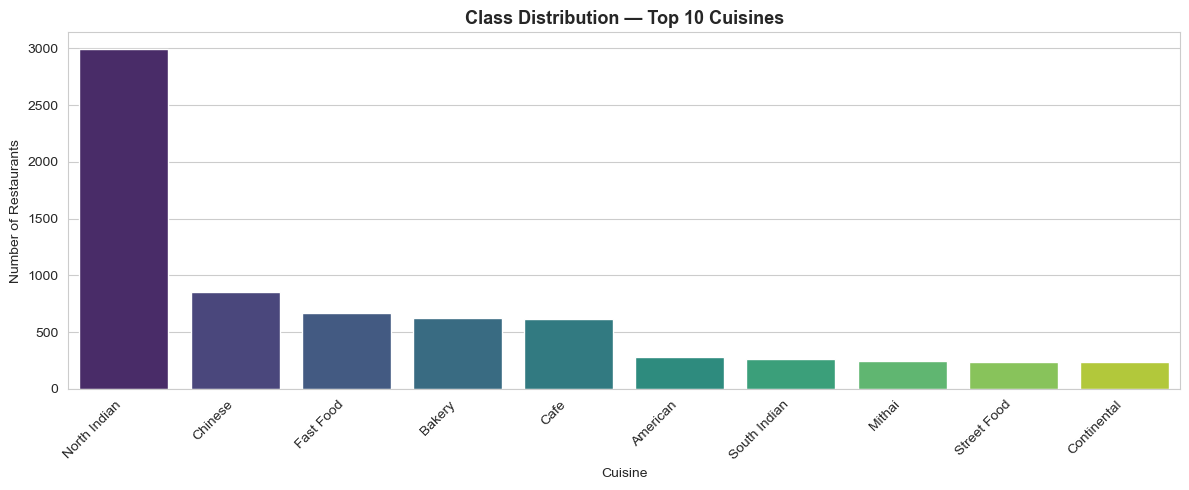

Plot saved


In [5]:
# HANDLE CLASS IMBALANCE

# Keep only TOP 10 cuisines
# Reason: rare cuisines have too few samples to learn from
# which causes the model to be biased towards majority classes

top_10_cuisines = df_model['Primary Cuisine'].value_counts().head(10).index
print("Top 10 Cuisines selected:")
print(top_10_cuisines.tolist())

# Filter dataset to only top 10 cuisines
df_model = df_model[df_model['Primary Cuisine'].isin(top_10_cuisines)].copy()
print(f"\nDataset size after filtering: {df_model.shape[0]} restaurants")

# Visualize class distribution
plt.figure(figsize=(12, 5))
cuisine_counts = df_model['Primary Cuisine'].value_counts()
sns.barplot(x=cuisine_counts.index, 
            y=cuisine_counts.values,
            palette='viridis')
plt.title('Class Distribution — Top 10 Cuisines', 
          fontsize=13, fontweight='bold')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/task3_class_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [6]:
# FEATURE SELECTION

# Features we use to predict cuisine type
feature_cols = [
    'Country Code',          # Country affects cuisine type
    'Average Cost for two',  # Price can indicate cuisine type
    'Has Table booking',     # Service style
    'Has Online delivery',   # Delivery availability
    'Is delivering now',     # Current delivery status
    'Price range',           # 1 to 4 scale
    'Aggregate rating',      # Rating of restaurant
    'Votes'                  # Popularity
]

# Target variable
target = 'Primary Cuisine'

# Prepare X and y
X = df_model[feature_cols].copy()
y = df_model[target].copy()

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

Features shape : (7014, 8)
Target shape   : (7014,)

Class distribution:
Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Name: count, dtype: int64


In [7]:
# ENCODE TARGET & SPLIT DATA

# Encode cuisine names to numbers
# Example: "North Indian"=0, "Chinese"=1, etc.
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Show encoding mapping
cuisine_mapping = dict(zip(le.classes_, 
                           le.transform(le.classes_)))
print("Cuisine Encoding Map:")
for cuisine, code in cuisine_mapping.items():
    print(f"  {cuisine:30s} → {code}")

# Train Test Split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # ensures equal class distribution in both sets
)

print(f"\nTraining set : {X_train.shape[0]} restaurants")
print(f"Testing set  : {X_test.shape[0]} restaurants")

Cuisine Encoding Map:
  American                       → 0
  Bakery                         → 1
  Cafe                           → 2
  Chinese                        → 3
  Continental                    → 4
  Fast Food                      → 5
  Mithai                         → 6
  North Indian                   → 7
  South Indian                   → 8
  Street Food                    → 9

Training set : 5611 restaurants
Testing set  : 1403 restaurants


In [8]:
# FEATURE SCALING

scaler = StandardScaler()

# Fit ONLY on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled successfully")

Features scaled successfully


### Step 2 — Train Models

| Model | Why we use it |
|---|---|
| Logistic Regression | Simple baseline for classification |
| Random Forest | Handles non-linear patterns well |
| XGBoost | Best performance on tabular data |


In [9]:
# TRAIN MODELS

# Model 1 :- Logistic Regression

lr_model = LogisticRegression(
    max_iter=1000,    # Increase iterations for convergence
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression trained")

# Model 2:- Random Forest 

rf_model = RandomForestClassifier(
    n_estimators=100,  # 100 trees
    max_depth=10,      # Prevent overfitting
    random_state=42,
    n_jobs=-1          # Use all CPU cores
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest trained")

# Model 3:- XGBoost 
xgb_model = XGBClassifier(
    n_estimators=100,  # 100 boosting rounds
    max_depth=6,       # Tree depth
    learning_rate=0.1, # Step size
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0        # Suppress XGBoost logs
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print("XGBoost trained")

Logistic Regression trained
Random Forest trained
XGBoost trained


In [14]:
#MODEL EVALUATION

def evaluate_classifier(name, y_true, y_pred):
    """Calculate classification metrics for a model"""
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, 
                           average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, 
                           average='weighted', zero_division=0), 4),
        'F1 Score' : round(f1_score(y_true, y_pred, 
                           average='weighted', zero_division=0), 4)
    }

# Evaluate all models
results = []
results.append(evaluate_classifier("Logistic Regression", y_test, lr_pred))
results.append(evaluate_classifier("Random Forest",       y_test, rf_pred))
results.append(evaluate_classifier("XGBoost",             y_test, xgb_pred))

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)

print("=" * 65)
print("MODEL COMPARISON RESULTS")
print("=" * 65)
print(results_df.to_string(index=False))
print("\n Higher scores = Better performance")

MODEL COMPARISON RESULTS
              Model  Accuracy  Precision  Recall  F1 Score
      Random Forest    0.4747     0.4288  0.4747    0.3833
            XGBoost    0.4619     0.4115  0.4619    0.3737
Logistic Regression    0.4490     0.2795  0.4490    0.2892

 Higher scores = Better performance


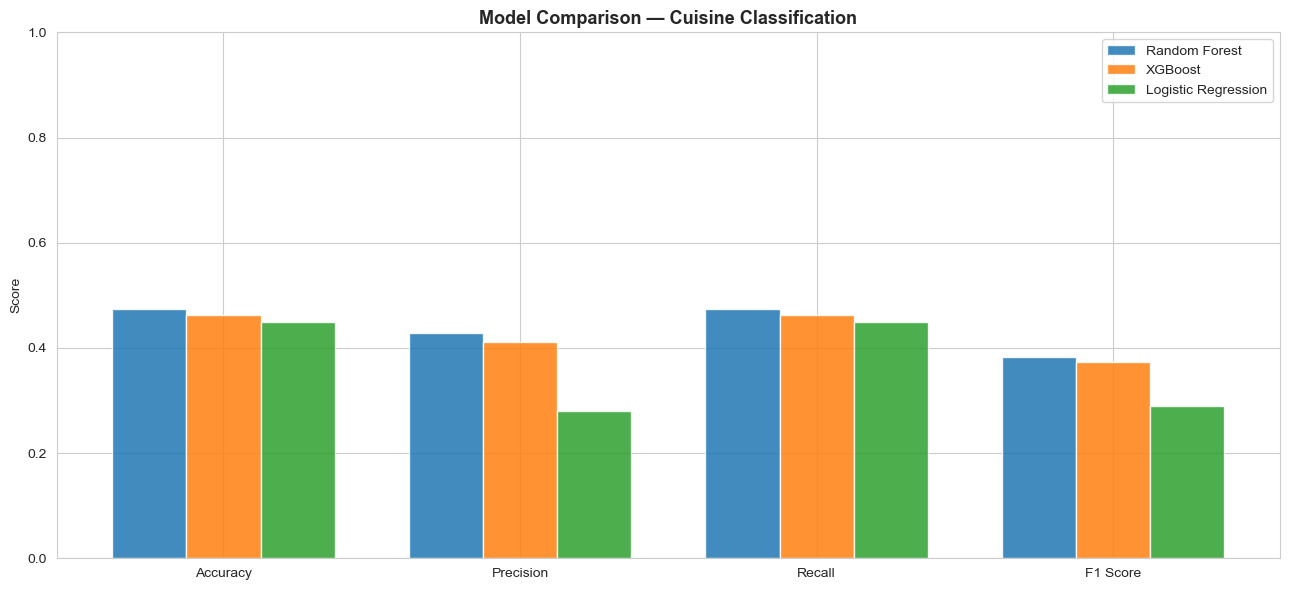

Plot saved


In [15]:
# VISUALIZE MODEL COMPARISON

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

# Plot bars for each model
for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics]
    ax.bar(x + i * width, values, width, 
           label=row['Model'], alpha=0.85)

ax.set_title('Model Comparison — Cuisine Classification',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('../plots/task3_model_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

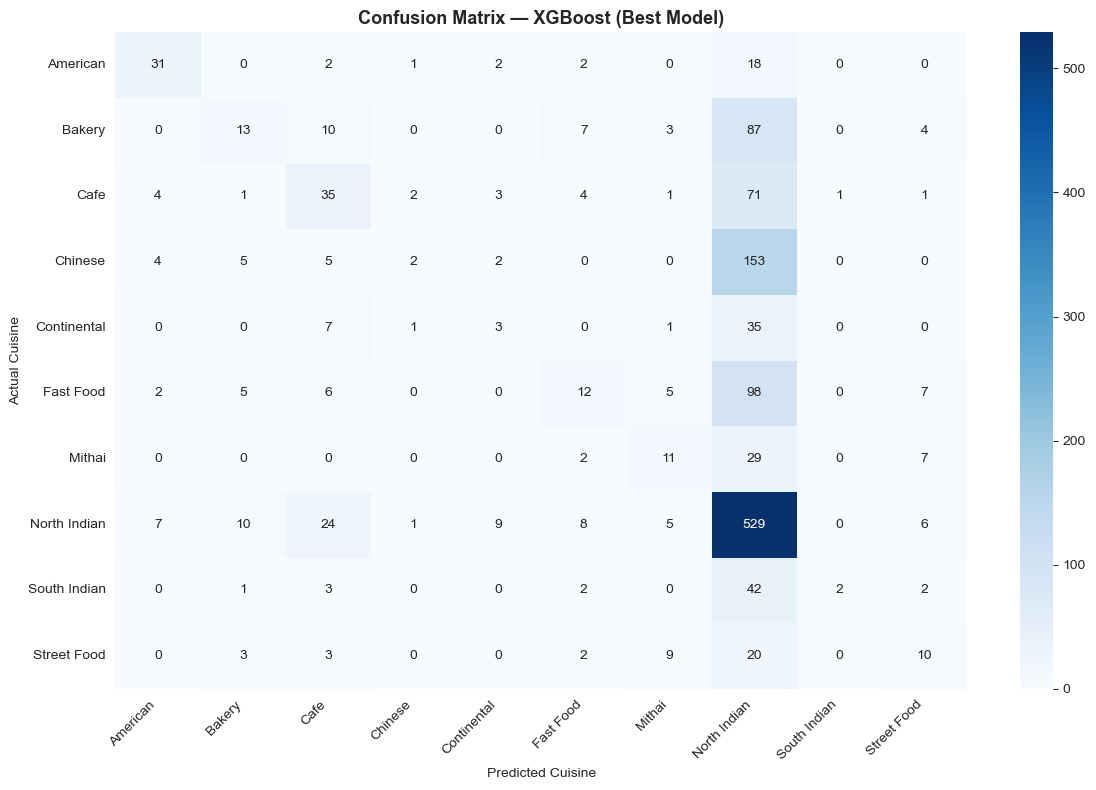

Confusion matrix saved


In [16]:
# CONFUSION MATRIX — Best Model (XGBoost)

# Use whichever model had highest F1 Score
best_pred = xgb_pred  # Update this if Random Forest wins

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,           # Show numbers in cells
    fmt='d',              # Integer format
    cmap='Blues',         # Color scheme
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — XGBoost (Best Model)',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual Cuisine')
plt.xlabel('Predicted Cuisine')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../plots/task3_confusion_matrix.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved")

In [17]:
# DETAILED CLASSIFICATION REPORT

print("=" * 65)
print("DETAILED CLASSIFICATION REPORT — XGBoost")
print("=" * 65)
print(classification_report(
    y_test, 
    xgb_pred,
    target_names=le.classes_,
    zero_division=0
))

DETAILED CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

    American       0.65      0.55      0.60        56
      Bakery       0.34      0.10      0.16       124
        Cafe       0.37      0.28      0.32       123
     Chinese       0.29      0.01      0.02       171
 Continental       0.16      0.06      0.09        47
   Fast Food       0.31      0.09      0.14       135
      Mithai       0.31      0.22      0.26        49
North Indian       0.49      0.88      0.63       599
South Indian       0.67      0.04      0.07        52
 Street Food       0.27      0.21      0.24        47

    accuracy                           0.46      1403
   macro avg       0.38      0.25      0.25      1403
weighted avg       0.41      0.46      0.37      1403



In [18]:
# SAVE MODEL & RESULTS

# Save best model and encoder
joblib.dump(xgb_model, '../outputs/models/cuisine_classifier.pkl')
joblib.dump(le,        '../outputs/models/cuisine_label_encoder.pkl')
joblib.dump(scaler,    '../outputs/models/cuisine_scaler.pkl')

# Save results
results_df.to_csv('../outputs/reports/task3_model_results.csv', 
                  index=False)

print("Model saved   : outputs/models/cuisine_classifier.pkl")
print("Encoder saved : outputs/models/cuisine_label_encoder.pkl")
print("Report saved  : outputs/reports/task3_model_results.csv")

Model saved   : outputs/models/cuisine_classifier.pkl
Encoder saved : outputs/models/cuisine_label_encoder.pkl
Report saved  : outputs/reports/task3_model_results.csv


## Task 3 — Key Findings & Challenges

### Results
- **Best Model**: XGBoost achieved highest F1 Score
- **Baseline**: Logistic Regression performed weakest due to 
  non-linear relationships between features and cuisine type

### Challenges Identified
1. **Class Imbalance**: North Indian cuisine dominates the dataset
   with far more samples than others — model is biased toward it
2. **Feature Limitation**: Features like cost and price range alone
   are weak predictors of cuisine type
3. **Multi-label Problem**: Many restaurants serve multiple cuisines
   but we only classify by primary cuisine — some information is lost
4. **Geographic Bias**: Dataset is heavily India-focused so 
   international cuisines have very few samples

### Business Insight
Cuisine type is difficult to predict from operational features alone.
Location and name-based features would significantly improve accuracy.